In [1]:
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import transformers

In [2]:
dataset = load_dataset("clapAI/MultiLingualSentiment")

In [3]:
train_ds = dataset["train"].shuffle(seed=42).select(range(512))
eval_ds = dataset["validation"].shuffle(seed=42).select(range(512))
test_ds = dataset["test"].shuffle(seed=42).select(range(512))

labels = train_ds.unique("label")
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for idx, label in enumerate(labels)}
num_labels = len(labels)

model_checkpoint = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

Flattening the indices:   0%|          | 0/512 [00:00<?, ? examples/s]

In [4]:
def preprocess_function(examples):
    tokenized = tokenizer(examples["text"], truncation=True, max_length=256)
    tokenized["label"] = [label2id[l] for l in examples["label"]]
    return tokenized


train_ds = train_ds.map(preprocess_function, batched=True).remove_columns(
    ["token_type_ids", "source", "domain", "text"])
eval_ds = eval_ds.map(preprocess_function, batched=True).remove_columns(["token_type_ids", "source", "domain", "text"])
test_ds = test_ds.map(preprocess_function, batched=True).remove_columns(["token_type_ids", "source", "domain", "text"])
print(train_ds[:2])

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

{'label': [0, 0], 'language': ['ko', 'ru'], 'input_ids': [[101, 9321, 16617, 10892, 79633, 28911, 8924, 30873, 77884, 100, 102], [101, 523, 63549, 36341, 12634, 10353, 50800, 119, 21124, 10351, 117, 10439, 54907, 119, 524, 104782, 10913, 37936, 10783, 28698, 66799, 119, 54640, 14122, 543, 80369, 30102, 119, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [5]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [6]:
metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]

    return {
        "accuracy": acc,
        "f1": f1
    }

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir=None,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    logging_steps=500,
    report_to="tensorboard"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.remove_callback(transformers.utils.notebook.NotebookProgressCallback)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
print("Starting training...")
trainer.train()

Starting training...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=48, training_loss=1.054685910542806, metrics={'train_runtime': 20.6074, 'train_samples_per_second': 74.536, 'train_steps_per_second': 2.329, 'total_flos': 99128778046272.0, 'train_loss': 1.054685910542806, 'epoch': 3.0})

In [9]:
print("Evaluating on test dataset...")
test_results = trainer.evaluate(test_ds)
print(f"Final Test Results: {test_results}")

Evaluating on test dataset...
Final Test Results: {'eval_loss': 1.077937126159668, 'eval_accuracy': 0.44921875, 'eval_f1': 0.40635797633430276, 'eval_runtime': 0.9221, 'eval_samples_per_second': 555.239, 'eval_steps_per_second': 8.676, 'epoch': 3.0}


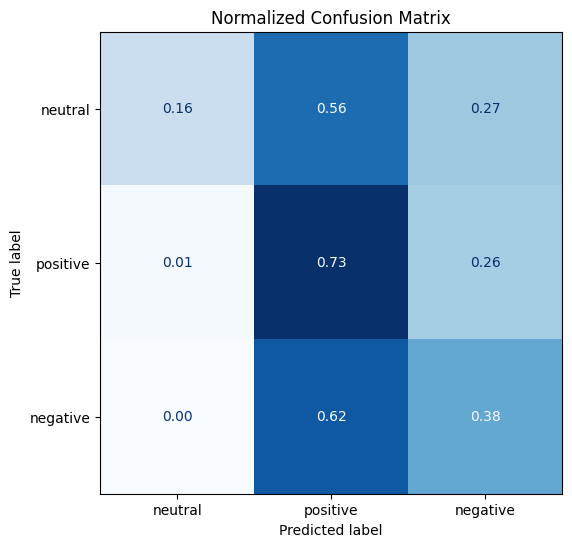

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt


def plot_confusion_matrix(y_preds, y_true, labels):
    """绘制归一化混淆矩阵"""
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized Confusion Matrix")
    plt.show()


test_results = trainer.predict(test_ds)

y_preds = np.argmax(test_results.predictions, axis=1)
y_true = test_results.label_ids

labels = [id2label[i] for i in sorted(id2label.keys())]

plot_confusion_matrix(y_preds, y_true, labels)